 Autoencoders on Fashion MNIST

## 1. Load and Visualize the Dataset

rq: late in space doit être égale à 2

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from tqdm import tqdm

1.2: Prepare the Data

In [30]:
# Téléchargement des datasets
#Q1: Load Fashion MNIST and set train=True for training data and train=False for validation data.
# Pour MNIST
mnist_train = datasets.FashionMNIST(root="./data", train=True, download=True)
mnist_val= datasets.FashionMNIST(root="./data", train=False, download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.06MB/s]


In [56]:
#Q2-Apply padding to increase the image size from 28×28 to 32×32
#Q2-Redimension et normalisation des images.
transform_mnist = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    # Removed transforms.Normalize((0.5,), (0.5,)) to ensure pixel values are between 0 and 1
])

Wrap the dataset in a DataLoader to allow efficient mini-batch processing.


In [57]:
#Pour jeu de données MNIST
mnist_train.transform = transform_mnist
mnist_val.transform = transform_mnist

In [59]:
train_loader= DataLoader(mnist_train, batch_size=64, shuffle=True)
val_loader = DataLoader(mnist_val, batch_size=64, shuffle=True)

###  1.3: Visualizing Sample Images
Extract a batch of images and labels from the training dataset.

Display multiple images in a grid.

Use matplotlib to plot the grayscale images.


In [60]:
class_labels = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}
def plot_sample_images(loader):
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    images = images.numpy()

    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(class_labels[labels[i].item()])
        plt.axis("off")


<Figure size 640x480 with 0 Axes>

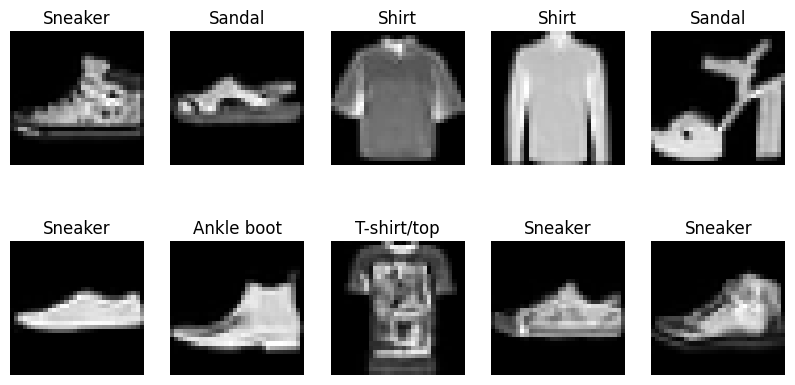

In [61]:
plt.tight_layout()
plt.show()
plot_sample_images(train_loader)


### 2. Build the Autoencoder

In [62]:
# Define the Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, input_shape=(1, 32, 32), latent_dim=10):
        """
        Initialize the Autoencoder model.
        - input_shape: The shape of the input images (1, 32, 32) for grayscale images.
        - latent_dim: The number of neurons in the latent space.
        """
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # First convolutional layer: Convert 1-channel input into 32 feature maps.
            nn.Conv2d(in_channels=input_shape[0], out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # activation function

            # Second convolutional layer: Reduce spatial dimensions further.
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # activation function

            # Third convolutional layer: Extract higher-level features.
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Dynamically calculate the flattened size after encoding
        flattened_size, decode_shape = self.calculate_flattened_size(self.encoder, input_shape)

        # Latent space (fully connected layer)
        self.fc = nn.Sequential(
            nn.Flatten(start_dim=1),  # Flatten the encoded features
            nn.Linear(flattened_size, latent_dim)  # Replace xxx with the latent dimension
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, flattened_size),  # Map latent space back to the feature map
            nn.Unflatten(1, decode_shape[1:]),  # Reshape to match the encoded feature map, batch dim is 0
            # Transposed Convolution layers (Decoder)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # Add a conv transpose 2d
            nn.ReLU(), # activation function

            # Next deconvolution layer
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # Add a ConvTranspose2d layer reducing from 64 channels to 32 channels and  kernel_size=3, stride=2, padding=1, output_padding=1
            nn.ReLU(), # activation function

            # Final deconvolution layer: Convert back to single-channel grayscale image
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # activation function: Output values should be between 0 and 1
        )

    def calculate_flattened_size(self, model, input_shape):
        """
        Helper function to determine the flattened size after the encoder.
        - model: The encoder model.
        - input_shape: The shape of the input tensor.
        Returns:
        - The flattened size (number of features) and output shape.
        """
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)  # Create a batch of one image
            output = model(dummy_input)
            return output.numel(), output.shape  # Return total number of elements and shape

    def forward(self, x):
        """
        Forward pass through the Autoencoder.
        - x: Input image tensor.
        Returns:
        - Reconstructed image
        - Latent space representation
        """
        encoded = self.encoder(x)  # Pass through the encoder
        latent = self.fc(encoded)  # Project into latent space
        decoded = self.decoder(latent)  # Decode the latent representation
        return decoded, latent

In [63]:
# Test dimension consistency
x_sample = torch.randn(1, 1, 32, 32)  # Example input
model_test = Autoencoder()
image_test,latent_space = model_test(x_sample)
assert image_test.shape == x_sample.shape, "Output dimensions do not match input dimensions!"

###  3-Train the Autoencoder

#### 3.1 Define the Training Process

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10
lr = 1e-4

In [65]:
model =Autoencoder().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

### 3.2 Evaluate the model

In [66]:
def train_model(model, train_loader, val_loader, epochs):
    """
    Train the Autoencoder model.

    - model: The Autoencoder instance.
    - train_loader: DataLoader for training data.
    - val_loader: DataLoader for validation data.
    - epochs: Number of training iterations.
    """

    model.to(device)# Move model to device
    optimizer = optim.Adam(model.parameters(), lr=1e-4) # Choose a suitable learning rate
    loss_fn = nn.MSELoss() # Define the loss function
    print("Start Training...")
    # Lists to store loss values for plotting
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train() # Set model to training mode
        total_loss = 0
        tqdm_loader = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for x, _ in tqdm_loader:
            x = x.to(device) # Move batch to device
             # Forward pass: get reconstructed output
            recon_x, _ = model(x)
            # Compute reconstruction loss loss = xxx  # Compute MSE loss between `recon_x` and `x`

            loss = loss_fn(recon_x, x)
            # Backpropagation
            optimizer.zero_grad()
            loss.backward() # Compute gradients
            optimizer.step() # Update weights

            total_loss += loss.item() # Accumulate batch loss
	    # Update tqdm progress bar with loss
            tqdm_loader.set_postfix(loss=loss.item())

        # Calculate average loss over the epoch
        avg_train_loss = total_loss / len(train_loader.dataset)
	    # for val get Mean Squared Error and cross_entropy
        avg_val_loss,ce_losss = evaluate_model(model, val_loader)
        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {100*avg_train_loss:.6f} %, Val Loss: {100*avg_val_loss:.6f} %,  Val Loss cross_entropy: {100*ce_losss:.6f} %")
    # Plot training and validation loss
    plot_training_loss(train_losses, val_losses)

# Evaluation function

In [67]:
def evaluate_model(model, loader):
    """
    Evaluate the model on validation data.

    - model: Trained Autoencoder model.
    - loader: DataLoader for validation data.

    Returns:
    - avg_loss: The average loss across all validation samples.
    """


    model.eval() # Set model to evaluation mode
    total_loss = 0
    loss_fn = nn.MSELoss() # Use the same loss function as training
    ce_losss=0
    with torch.no_grad():  # No need to compute gradients
        for x, _ in tqdm(loader, desc="Evaluating"):
            x = x.to(device)
            recon_x,_ = model(x) # Get reconstruction
            loss = loss_fn(recon_x, x) # Compute loss between recon_x and x
            ce_loss= F.binary_cross_entropy(recon_x, x )
            total_loss += loss.item()
            ce_losss+=ce_loss

    avg_loss = total_loss / len(loader.dataset)
    ce_losss/=len(loader.dataset)
    return avg_loss,ce_losss

def plot_training_loss(train_losses, val_losses):
    """
    Plot the training and validation loss across epochs.

    - train_losses: List of training losses per epoch.
    - val_losses: List of validation losses per epoch.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Training Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="s")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

# Instantiate and train the model


Start Training...


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 19.91it/s]


Epoch [1/10], Train Loss: 0.068657 %, Val Loss: 0.029506 %,  Val Loss cross_entropy: 0.521806 %


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.77it/s]


Epoch [2/10], Train Loss: 0.025293 %, Val Loss: 0.022342 %,  Val Loss cross_entropy: 0.497388 %


...

Epoch [8/10], Train Loss: 0.015897 %, Val Loss: 0.015903 %,  Val Loss cross_entropy: 0.476331 %


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.12it/s]


Epoch [9/10], Train Loss: 0.015571 %, Val Loss: 0.015606 %,  Val Loss cross_entropy: 0.475530 %


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 19.86it/s]


Epoch [10/10], Train Loss: 0.015298 %, Val Loss: 0.015413 %,  Val Loss cross_entropy: 0.474739 %


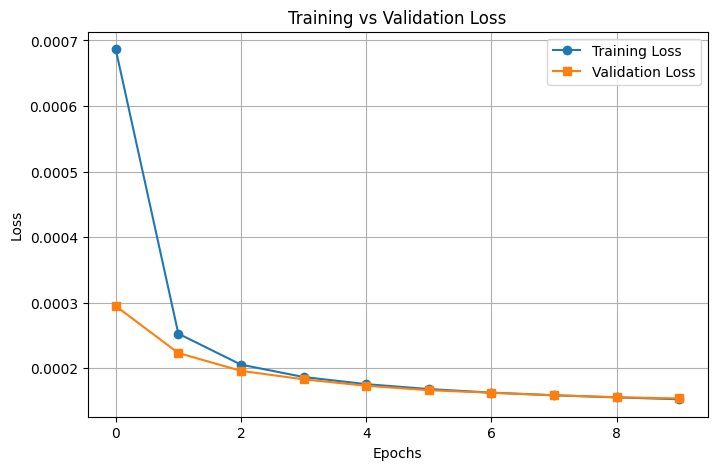

In [68]:
autoencoder = Autoencoder()
train_model(autoencoder, train_loader, val_loader, epochs=num_epochs)

### Reconstruct Images Using the Autoencoder

4.1: Extract a Few Test Images

Select a batch of images from the validation dataset.

Pass them through the Autoencoder.

Retrieve the reconstructed images.

4.2: Compare Original vs Reconstructed Images

Plot the original images in the top row.

Plot the reconstructed images in the bottom row.

Observe the differences.


In [72]:
# Function to plot reconstructions
def plot_reconstructions(model, loader, ex=True):
    model.eval()  # Set the model to evaluation mode
    model = model.to("cpu")  # Move model to CPU for visualization

    with torch.no_grad():
        if ex:
            for x, _ in loader:  # Extract a batch from DataLoader
                recon_x, _ = model(x)
                break
        else:
            x = loader  # Directly use provided latent vectors
            recon_x = model.decoder(x)  # Decode latent space samples

    # Convert tensors to NumPy for plotting
    x = x.cpu().numpy()
    recon_x = recon_x.cpu().numpy()

    plt.figure(figsize=(10, 5))
    for i in range(5):
        # Plot Original images (only if batch came from real data)
         if ex:
            plt.subplot(2, 5, i + 1)
            plt.imshow(x[i].squeeze(), cmap="gray")
            plt.title("Original")
            plt.axis("off")

        # Plot Reconstructed images
        plt.subplot(2, 5, i + 6)
        plt.imshow(recon_x[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_reconstructions(autoencoder, val_loader)


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 29)

  5.Visualize the Latent Space

5.1: Extract Embeddings

Pass multiple images through the encoder.

Store the latent representations and labels.
